# TP3 - Carga y Descarga de un Capacitor

**Materia:** Electricidad y Magnetismo

**Integrantes:**
* Fernanda Perez
* Tomas Aragusuku
* Jonathan Gomez
* Carla Rocca

## 1. Objetivo
Antes de la instancia de medición, la cátedra nos pidió una **muestra teórica** del comportamiento de carga y descarga de un capacitor de $C = 2\mu F$ en serie con una resistencia de $R = 150\Omega$.

El objetivo de este notebook es:
1. Calcular la constante de tiempo $\tau = R.C$ del circuito.
2. Graficar la tensión $V_C(t)$ y la corriente $I(t)$ esperadas para una onda cuadrada de **200 Hz** (la frecuencia con la que se hizo la medición): $2,5\,ms$ de carga y $2,5\,ms$ de descarga, es decir un período $T = 5\,ms$, repitiendo el ciclo para verificar la periodicidad.
3. Usar estos resultados teóricos como referencia para la escala de tiempo del osciloscopio y para comparar contra los datos experimentales medidos, en las mismas condiciones de frecuencia (última sección).

## 2. Materiales y montaje

Para la medición se usó:

* **Generador de funciones** GW Instek AFG-2005, como fuente de la onda cuadrada que carga y descarga el capacitor. Según las especificaciones del fabricante, su **impedancia de salida es de $50\,\Omega$**.
* **Osciloscopio digital** GW Instek GDS-1102A-U, para registrar la tensión en el capacitor. Su impedancia de entrada ($1\,M\Omega$) es mucho mayor que $R$, así que no altera el circuito.
* **Resistencia** de $R = 150\,\Omega$ y **capacitor** de $C = 2\,\mu F$, montados sobre plaquetas en un soporte.
* **Cables** con conectores BNC y pinzas cocodrilo para las conexiones.

El montaje consistió en conectar la resistencia y el capacitor **en serie** a la salida del generador, y el canal 1 del osciloscopio **en paralelo con el capacitor**, para medir $V_C(t)$. El generador se configuró en onda cuadrada de $200\,Hz$, $5\,V_{pp}$ y offset $0\,V$, y el osciloscopio en $500\,mV/div$ y $1\,ms/div$. Una vez estabilizada la señal en pantalla, se guardó la captura en un archivo CSV para analizarla (sección 7).

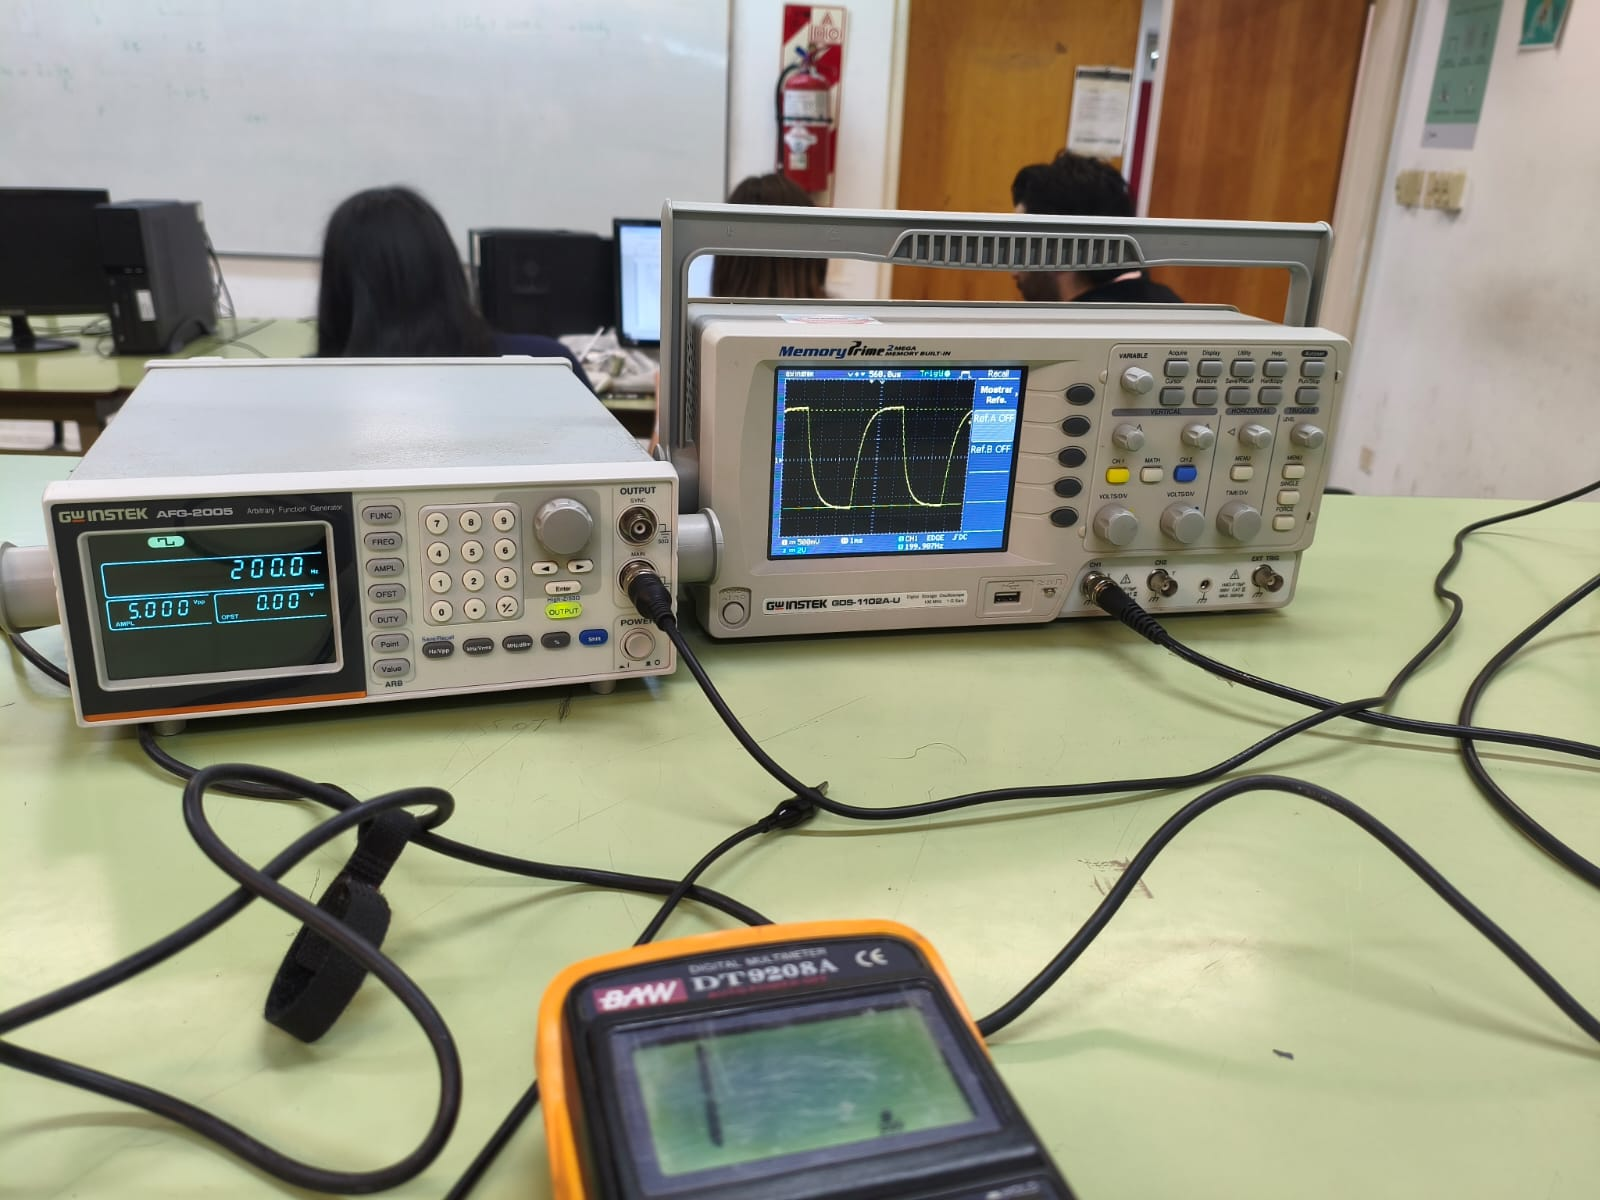

*Figura 1: montaje completo, con el generador de funciones (izquierda) y el osciloscopio (derecha).*

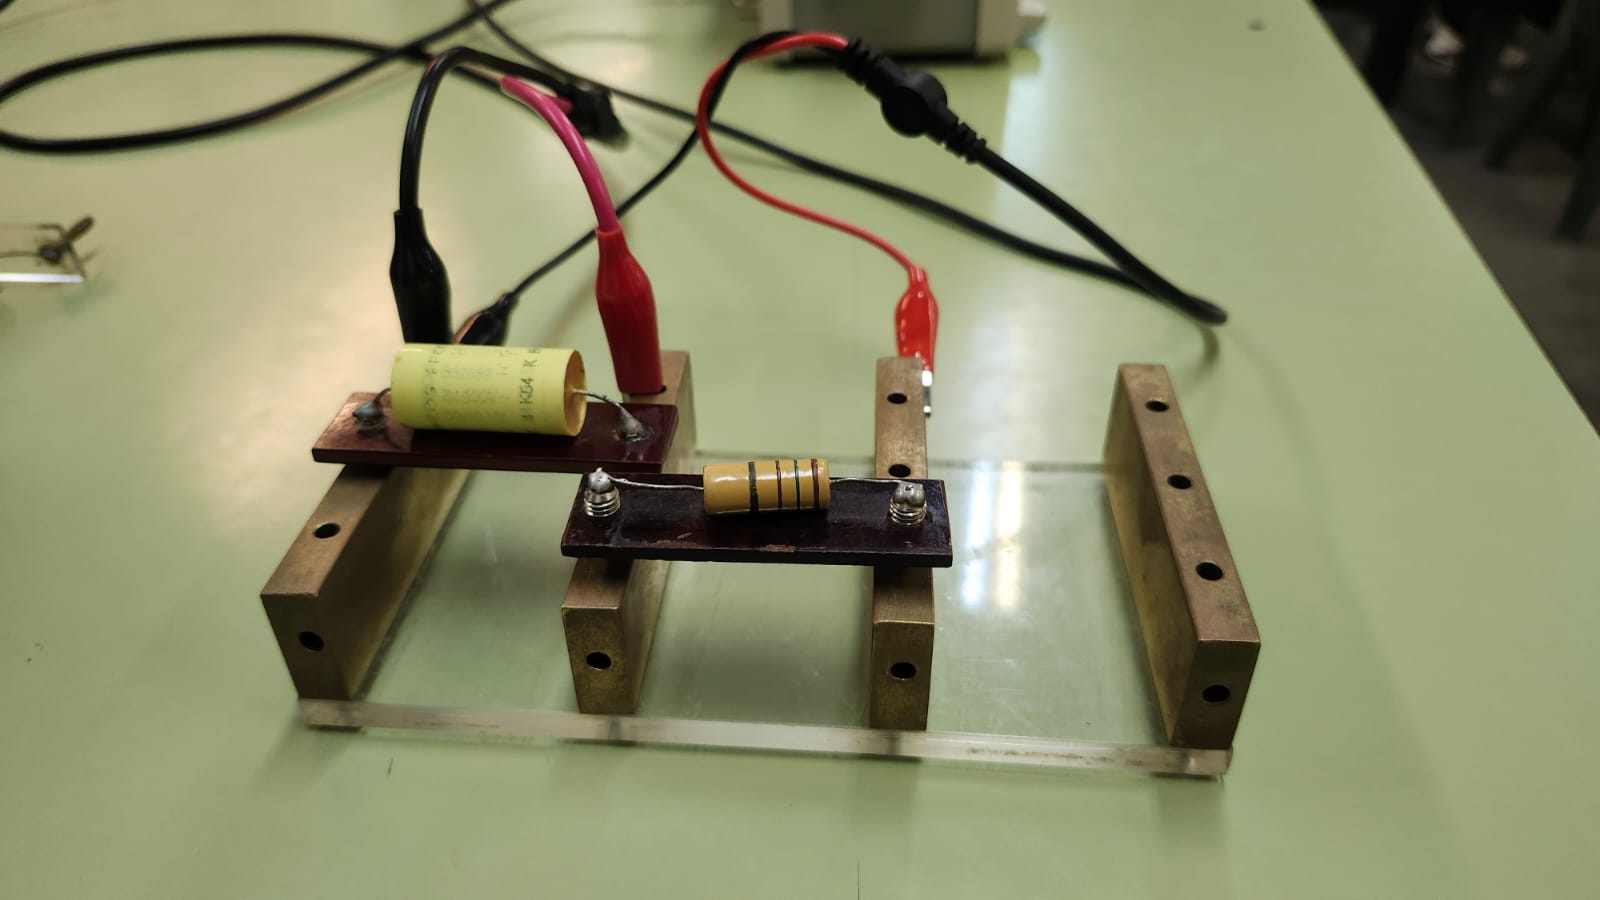

*Figura 2: circuito RC, con el capacitor (amarillo) y la resistencia en serie.*

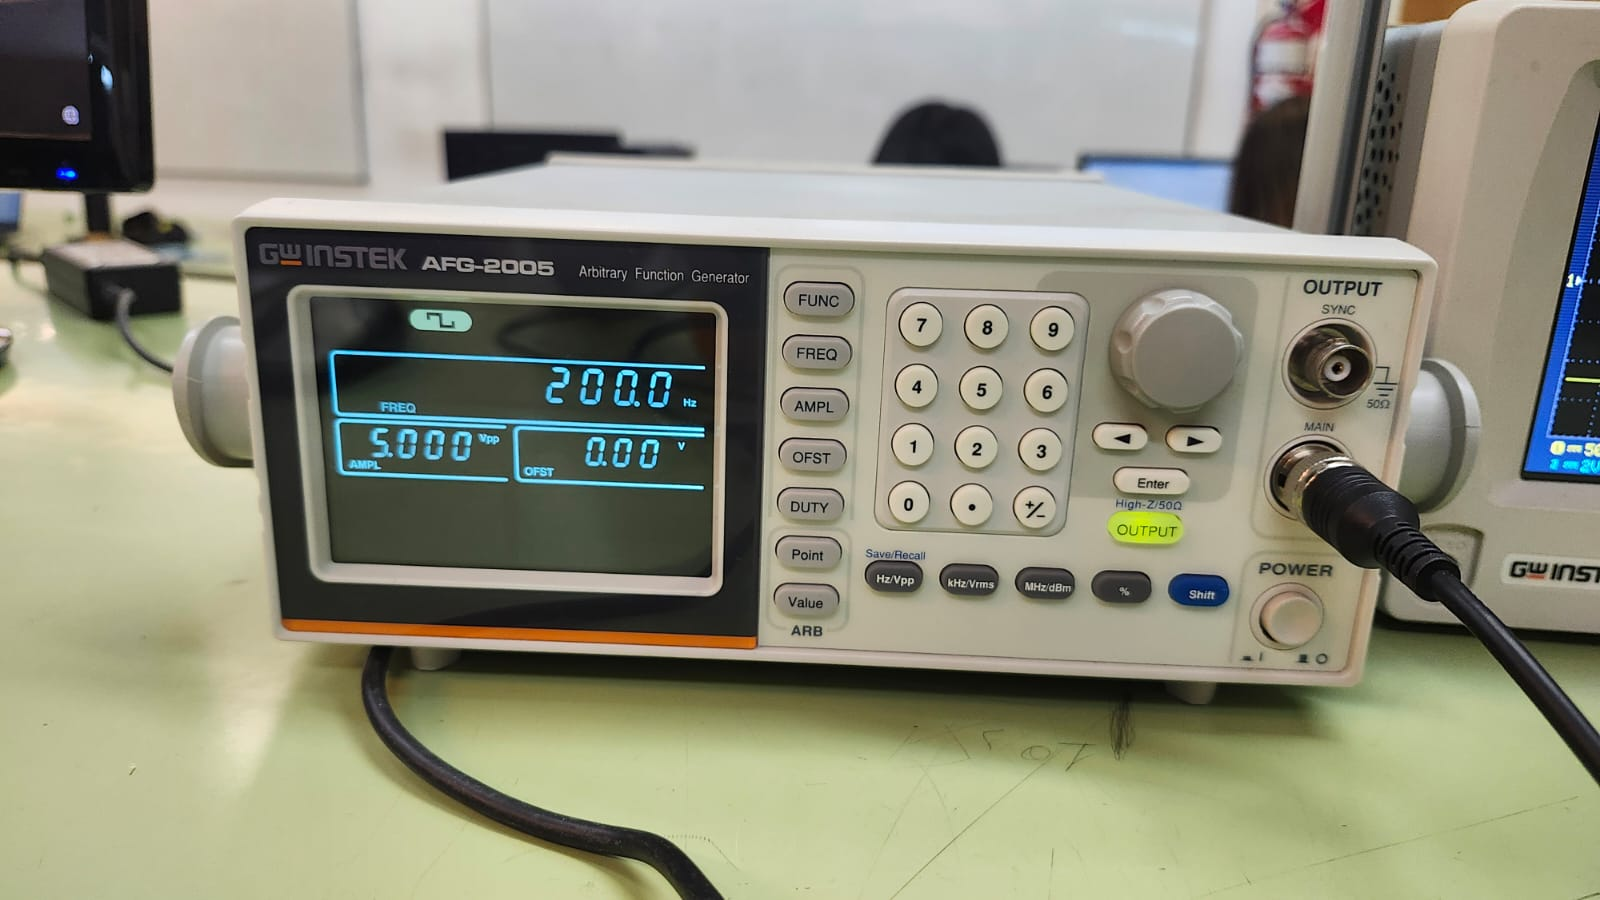

*Figura 3: generador de funciones configurado en onda cuadrada de $200\,Hz$, $5\,V_{pp}$ y offset $0\,V$.*

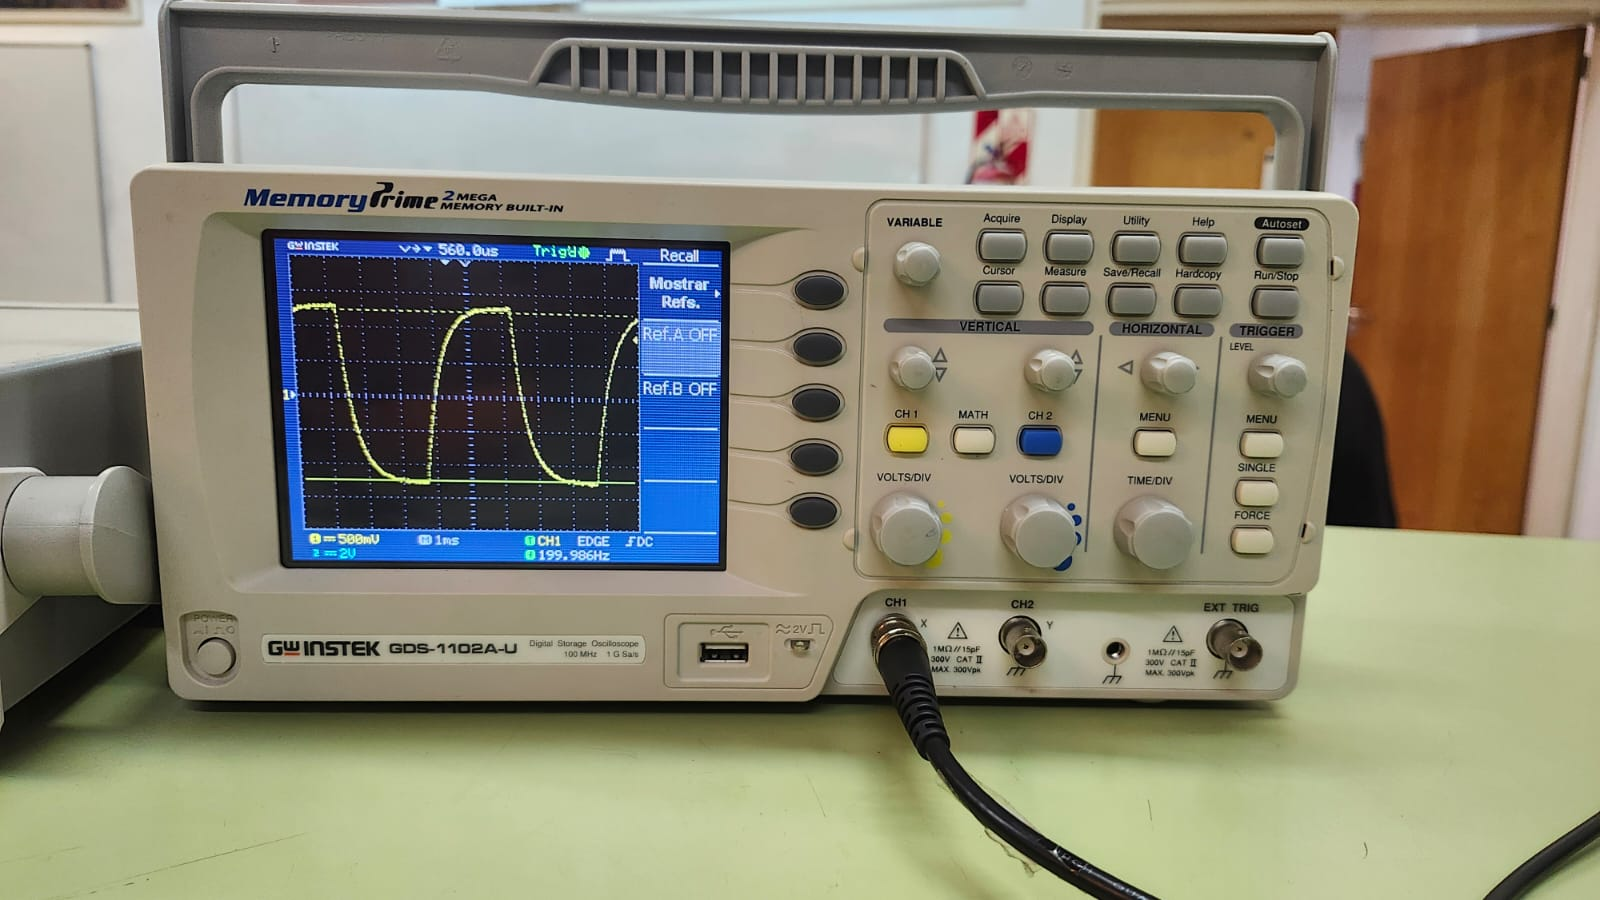

*Figura 4: señal de carga y descarga del capacitor en el osciloscopio.*

## 3. Introducción teórica

Un capacitor conectado en serie con una resistencia forma un circuito **RC**. Si se lo alimenta con una tensión $V_0$ (por ejemplo, la salida de un generador de funciones en modo onda cuadrada), el capacitor se **carga** mientras la fuente está conectada y se **descarga** a través de la resistencia cuando la fuente se cortocircuita o se desconecta.

**Carga:**
$$V_C(t) = V_0\left(1 - e^{-t/\tau}\right) \qquad I(t) = \frac{V_0}{R}\,e^{-t/\tau}$$

**Descarga:**
$$V_C(t) = V_0\,e^{-t/\tau} \qquad I(t) = -\frac{V_0}{R}\,e^{-t/\tau}$$

donde $\tau = R.C$ es la **constante de tiempo** del circuito. El signo negativo en la corriente de descarga indica que circula en sentido opuesto al de la carga, aunque su módulo responde a la misma exponencial.

Una propiedad útil de la exponencial es que en $t = 5\tau$ el capacitor ya alcanzó más del **99,3%** de su valor final ($1 - e^{-5} \approx 0,993$). Por eso, si se alimenta el circuito con una señal cuadrada cuyo semiperíodo dura al menos unos $5\tau$, el capacitor alcanza a completar prácticamente toda la carga y toda la descarga dentro de cada semiperíodo, y el patrón se repite de forma periódica en el osciloscopio.

## 4. Elección de los parámetros

$R = 150\,\Omega$ y $C = 2\,\mu F$ son los valores del circuito. La tensión $V_0$ quedaba a elección del grupo; elegimos **$V_0 = 5V$** porque:

* Es un valor estándar de fuente/generador de laboratorio, fácil de fijar con precisión.
* Da una corriente inicial de carga y una tensión final cómodas de leer tanto en el osciloscopio como en el multímetro.
* Conviene revisar la potencia que va a disipar la resistencia en el peor caso (capacitor descargado, $t=0$), para elegir una $R$ de potencia nominal adecuada. Esto se calcula en la siguiente celda.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Parámetros del circuito (R y C del circuito, V0 elegido por el grupo)
R = 150        # Resistencia [ohm]
C = 2e-6       # Capacidad [F]
V0 = 5         # Tensión de la fuente [V]

tau = R * C            # Constante de tiempo RC
f = 200                # Frecuencia de la onda cuadrada del generador [Hz] (la usada en la medición)
T = 1 / f              # Período completo de un ciclo carga+descarga
t_fase = T / 2         # Duración de cada fase (carga o descarga)

print(f"tau          = {tau*1e3:.3f} ms")
print(f"f            = {f} Hz")
print(f"T = 1/f      = {T*1e3:.3f} ms")
print(f"cada fase    = {t_fase*1e3:.3f} ms = {t_fase/tau:.1f} tau")
print(f"(criterio de diseño de 5*tau por fase: f = {1/(10*tau):.1f} Hz)")


tau          = 0.300 ms
f            = 200 Hz
T = 1/f      = 5.000 ms
cada fase    = 2.500 ms = 8.3 tau
(criterio de diseño de 5*tau por fase: f = 333.3 Hz)


In [3]:
# Corriente y potencia en el instante más exigente (t=0 de la carga, capacitor descargado)
I0 = V0 / R
P0 = V0**2 / R

print(f"I0 (t=0, carga) = {I0*1e3:.2f} mA")
print(f"P0 (t=0, carga) = {P0*1e3:.1f} mW")


I0 (t=0, carga) = 33.33 mA
P0 (t=0, carga) = 166.7 mW


Con $V_0 = 5V$, la corriente inicial es de aproximadamente **33,3 mA** y la potencia disipada en la resistencia en ese instante es de **~167 mW**. Una resistencia común de $1/4W$ (250 mW) alcanza, aunque trabajaría al ~67% de su potencia nominal; para tener más margen conviene usar una $R$ de $150\Omega$ de $1/2W$.

## 5. Construcción de las curvas teóricas

Armamos las curvas de $V_C(t)$ e $I(t)$ concatenando fases de carga y descarga de $2,5\,ms$ cada una (semiperíodo de la onda cuadrada de $200\,Hz$), repitiendo el ciclo dos veces para verificar la periodicidad.

In [4]:
n_ciclos = 2     # cantidad de ciclos carga+descarga a graficar
n_puntos = 300   # puntos por fase (resolución de la curva)

t_list, v_list, i_list = [], [], []
t_acumulado = 0.0

for ciclo in range(n_ciclos):
    # --- Fase de carga ---
    t = np.linspace(0, t_fase, n_puntos)
    v = V0 * (1 - np.exp(-t / tau))
    i = (V0 / R) * np.exp(-t / tau)

    t_list.append(t + t_acumulado)
    v_list.append(v)
    i_list.append(i)
    t_acumulado += t_fase

    # --- Fase de descarga ---
    t = np.linspace(0, t_fase, n_puntos)
    v = V0 * np.exp(-t / tau)
    i = -(V0 / R) * np.exp(-t / tau)   # mismo módulo, sentido opuesto a la carga

    t_list.append(t + t_acumulado)
    v_list.append(v)
    i_list.append(i)
    t_acumulado += t_fase

t_total = np.concatenate(t_list)
v_total = np.concatenate(v_list)
i_total = np.concatenate(i_list)


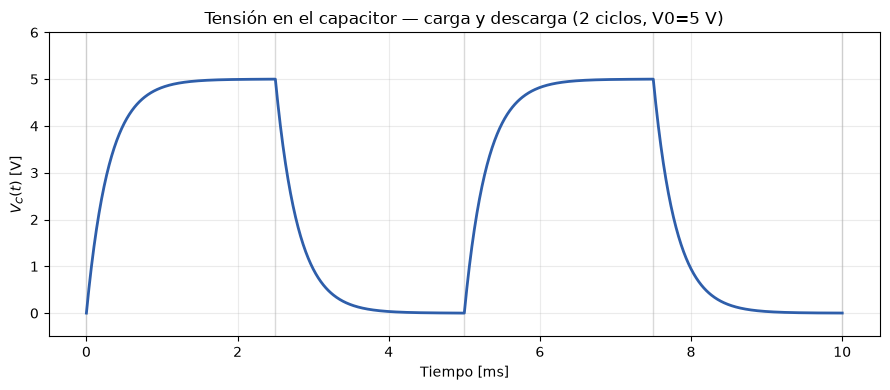

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_total * 1e3, v_total, color="#2E5EAA", linewidth=2)

for k in range(2 * n_ciclos + 1):
    ax.axvline(k * t_fase * 1e3, color="0.85", linewidth=1, zorder=0)

ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel(r"$V_C(t)$ [V]")
ax.set_title(f"Tensión en el capacitor \u2014 carga y descarga ({n_ciclos} ciclos, V0={V0} V)")
ax.grid(alpha=0.25)
ax.set_ylim(-0.5, V0 + 1)
fig.tight_layout()
plt.show()


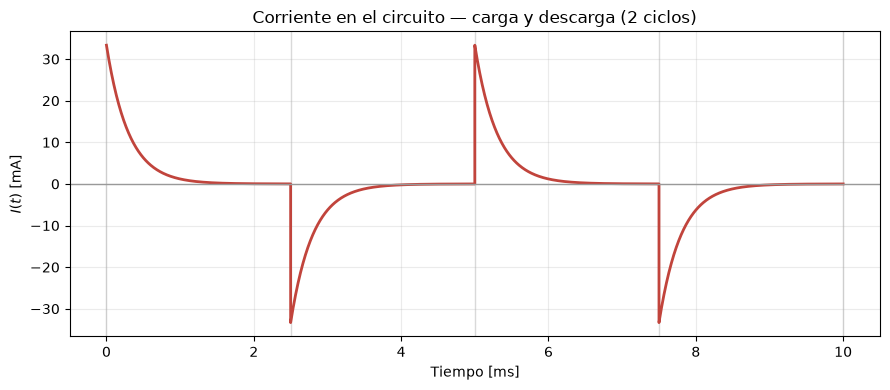

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_total * 1e3, i_total * 1e3, color="#C1443C", linewidth=2)
ax.axhline(0, color="0.6", linewidth=1)

for k in range(2 * n_ciclos + 1):
    ax.axvline(k * t_fase * 1e3, color="0.85", linewidth=1, zorder=0)

ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel(r"$I(t)$ [mA]")
ax.set_title(f"Corriente en el circuito \u2014 carga y descarga ({n_ciclos} ciclos)")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## 6. Análisis

* En cada semiperíodo de $2,5\,ms$ ($\approx 8,3\tau$) la tensión $V_C(t)$ llega prácticamente a $V_0$ (carga) o a $0V$ (descarga), lo que confirma que el período $T = 5\,ms$ alcanza para observar el ciclo completo sin cortarlo.
* La corriente $I(t)$ tiene la misma forma exponencial en ambas fases, pero cambia de signo entre carga y descarga porque el sentido de circulación se invierte.
* Con $\tau \approx 0,30\,ms$, el fenómeno completo dura unos pocos milisegundos: **no se puede seguir a ojo con un cronómetro**, por lo que la medición real requiere un generador de funciones en $200\,Hz$ (onda cuadrada) y un osciloscopio con una base de tiempo de pocos $ms/div$.

## 7. Mediciones con el osciloscopio

Con el circuito armado se capturó la tensión en el capacitor con el osciloscopio. El archivo `datos/DS0000.CSV` tiene la configuración de la captura (encabezado) y 4000 muestras crudas, en cuentas del conversor A/D. Se convierten a volts con la escala vertical del encabezado (25 cuentas por división) y el tiempo se arma con el período de muestreo.

In [7]:
# Lectura del CSV del osciloscopio: encabezado + datos crudos
with open("datos/DS0000.CSV") as archivo:
    lineas = archivo.read().splitlines()

encabezado = {}
for k, linea in enumerate(lineas):
    campos = linea.split(",")
    if campos[0] == "Waveform Data":
        i_datos = k + 1
        break
    encabezado[campos[0]] = campos[1]

raw = np.array([float(l.split(",")[0]) for l in lineas[i_datos:] if l.strip()])
v_div = float(encabezado["Vertical Scale"])   # [V/div]
dt = float(encabezado["Sampling Period"])     # [s]

t_med = np.arange(len(raw)) * dt
v_med = raw * v_div / 25                      # 25 cuentas por división vertical

# Niveles alto y bajo de la señal (mediana de los extremos, para no depender del ruido)
v_alto = np.median(v_med[v_med > np.percentile(v_med, 90)])
v_bajo = np.median(v_med[v_med < np.percentile(v_med, 10)])

print(f"Muestras: {len(raw)}  |  período de muestreo: {dt*1e6:.0f} us  |  duración: {t_med[-1]*1e3:.1f} ms")
print(f"Nivel alto  = {v_alto:.2f} V")
print(f"Nivel bajo  = {v_bajo:.2f} V")
print(f"Excursión   = {v_alto - v_bajo:.2f} V pico a pico")

Muestras: 4000  |  período de muestreo: 4 us  |  duración: 16.0 ms
Nivel alto  = 1.32 V
Nivel bajo  = -1.26 V
Excursión   = 2.58 V pico a pico


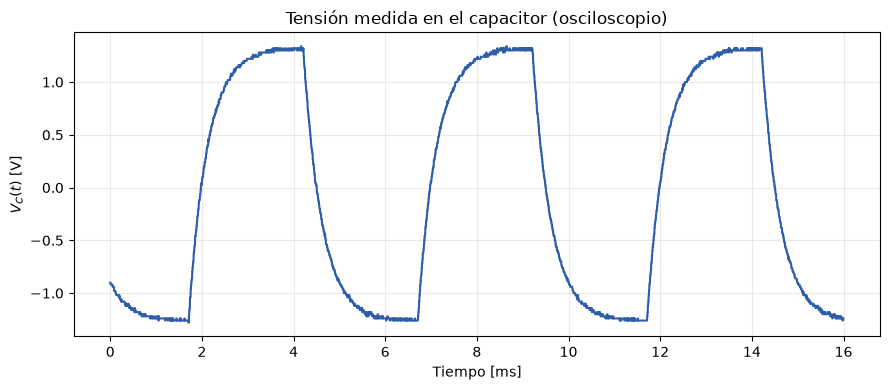

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_med * 1e3, v_med, color="#2E5EAA", linewidth=1.5)
ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel(r"$V_C(t)$ [V]")
ax.set_title("Tensión medida en el capacitor (osciloscopio)")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### 7.1. Constante de tiempo medida

Como $V_C(t)$ es una exponencial, se puede sacar $\tau$ de la parte de cada flanco que va hacia su valor final. Con $y$ la señal normalizada entre el nivel bajo (0) y el alto (1), lo que **falta** para llegar al valor final es $e^{-t/\tau}$ en cada flanco (en la carga $1-y$, en la descarga $y$). Entonces $\ln(\text{falta})$ es una recta en $t$ de pendiente $-1/\tau$.

`np.polyfit` ajusta **polinomios**, no exponenciales, así que no se lo podemos pedir directamente sobre $V_C(t)$ (que es una exponencial, no un polinomio). Por eso no le pasamos la señal cruda: le pasamos `np.log(falta)`, que es lineal en $t$, y le pedimos un polinomio de **grado 1** (una recta) para esos datos ya linealizados. La pendiente de esa recta es $-1/\tau$ y el ajuste es por cuadrados mínimos, igual que cualquier `polyfit`.

Una consecuencia de linealizar con el logaritmo es que los puntos donde `falta` es chica (al final de cada flanco, cuando el capacitor ya casi terminó de cargarse) pesan más en el ajuste que si se ajustara la exponencial directamente con un método no lineal — el logaritmo de un número chico cambia mucho ante variaciones chicas de ruido. Por eso se filtran esos extremos (celda siguiente, `ok = (falta > 0.03) & (falta < 0.95)`), para no dejar que el ruido de los bordes de cada flanco domine el ajuste.

In [9]:
y = (v_med - v_bajo) / (v_alto - v_bajo)      # 0 = nivel bajo, 1 = nivel alto

# Cruces por la mitad de la señal (0,5): hacia arriba = flanco de carga, hacia abajo = descarga
cruce_sube = np.where((y[:-1] < 0.5) & (y[1:] >= 0.5))[0]
cruce_baja = np.where((y[:-1] > 0.5) & (y[1:] <= 0.5))[0]

# El ruido genera cruces repetidos (incluso de signo contrario) sobre un mismo flanco:
# nos quedamos con el primero de cada grupo, separando los flancos reales por al menos 1 ms
flancos = []
for i, es_carga in sorted([(i, True) for i in cruce_sube] + [(i, False) for i in cruce_baja]):
    if not flancos or i - flancos[-1][0] > int(1e-3 / dt):
        flancos.append((i, es_carga))

def ajustar_tau(i, es_carga, ventana=1.6e-3):
    a = i - int(0.2e-3 / dt)
    b = min(i + int(ventana / dt), len(y))
    falta = (1 - y[a:b]) if es_carga else y[a:b]
    ok = (falta > 0.03) & (falta < 0.95)       # fuera del piso de ruido y del tramo plano previo
    pend, ordenada = np.polyfit(t_med[a:b][ok], np.log(falta[ok]), 1)
    return -1 / pend, -ordenada / pend         # tau y el instante t0 en que empieza el flanco

taus_carga, taus_descarga = [], []
for i, es_carga in flancos:
    tau_i, t0_i = ajustar_tau(i, es_carga)
    (taus_carga if es_carga else taus_descarga).append(tau_i)
    print(f"{'Carga   ' if es_carga else 'Descarga'} en t = {t0_i*1e3:6.2f} ms  ->  tau = {tau_i*1e3:.3f} ms")

tau_med = np.mean(taus_carga + taus_descarga)
tau_std = np.std(taus_carga + taus_descarga, ddof=1)
tau_teo = R * C
print(f"\ntau medido  = {tau_med*1e3:.3f} ms  (+/- {tau_std*1e3:.3f} ms, dispersión entre flancos)")
print(f"tau teórico = {tau_teo*1e3:.3f} ms  (R*C con R = {R} ohm)")
print(f"Diferencia  = {(tau_med - tau_teo) / tau_teo * 100:+.0f} %")

Carga    en t =   1.70 ms  ->  tau = 0.412 ms
Descarga en t =   4.22 ms  ->  tau = 0.397 ms
Carga    en t =   6.71 ms  ->  tau = 0.408 ms
Descarga en t =   9.22 ms  ->  tau = 0.396 ms
Carga    en t =  11.70 ms  ->  tau = 0.411 ms
Descarga en t =  14.21 ms  ->  tau = 0.398 ms

tau medido  = 0.404 ms  (+/- 0.008 ms, dispersión entre flancos)
tau teórico = 0.300 ms  (R*C con R = 150 ohm)
Diferencia  = +35 %


### 7.1.1. Capacidad medida a partir de $\tau$

$R$ es un valor conocido con bastante precisión (resistencia de película, tolerancia típica $\pm 5\%$), mientras que $C$ es la incógnita real: un capacitor común tiene tolerancias de fabricación de $\pm 10$ a $20\%$, así que el "$2\,\mu F$" de la etiqueta es solo un valor nominal. Por eso, en vez de comparar $\tau_{medido}$ contra $\tau_{teórico} = RC$ nominal, conviene despejar la capacidad real a partir de lo que sí medimos:

$$\tau = RC \quad\Longrightarrow\quad C = \frac{\tau}{R}$$

Se calcula $C$ para cada uno de los 6 flancos (con su $\tau_i$ ya ajustado arriba) y se la compara contra el valor nominal.

In [10]:
taus_todos = taus_carga + taus_descarga
C_por_flanco = [tau_i / R for tau_i in taus_todos]

C_medido = np.mean(C_por_flanco)
C_std = np.std(C_por_flanco, ddof=1)
C_nominal = C

print("Capacidad medida en cada flanco:")
for i, C_i in enumerate(C_por_flanco, 1):
    print(f"  Flanco {i}: C = {C_i*1e6:.3f} uF")

print(f"\nC medido   = ({C_medido*1e6:.3f} +/- {C_std*1e6:.3f}) uF  (dispersión entre flancos)")
print(f"C nominal  = {C_nominal*1e6:.1f} uF")
print(f"Diferencia = {(C_medido - C_nominal) / C_nominal * 100:+.0f} %")

Capacidad medida en cada flanco:
  Flanco 1: C = 2.749 uF
  Flanco 2: C = 2.722 uF
  Flanco 3: C = 2.742 uF
  Flanco 4: C = 2.646 uF
  Flanco 5: C = 2.641 uF
  Flanco 6: C = 2.656 uF

C medido   = (2.693 +/- 0.050) uF  (dispersión entre flancos)
C nominal  = 2.0 uF
Diferencia = +35 %


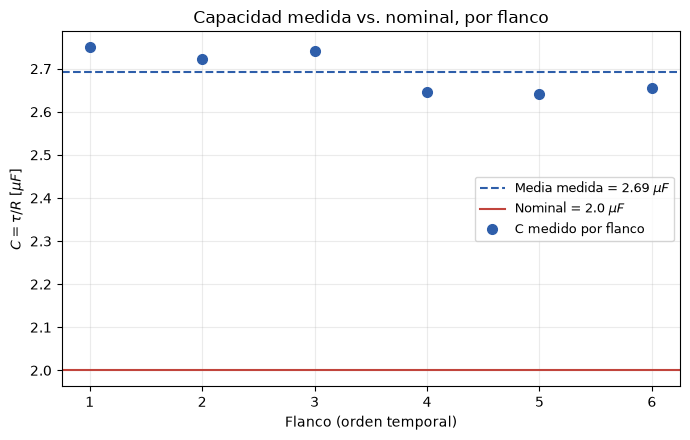

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
flancos_idx = np.arange(1, len(C_por_flanco) + 1)
ax.errorbar(flancos_idx, np.array(C_por_flanco) * 1e6, fmt="o", color="#2E5EAA",
            markersize=7, label="C medido por flanco")
ax.axhline(C_medido * 1e6, color="#2E5EAA", linestyle="--", linewidth=1.5,
           label=fr"Media medida = {C_medido*1e6:.2f} $\mu F$")
ax.axhline(C_nominal * 1e6, color="#C1443C", linewidth=1.5,
           label=fr"Nominal = {C_nominal*1e6:.1f} $\mu F$")
ax.set_xticks(flancos_idx)
ax.set_xlabel("Flanco (orden temporal)")
ax.set_ylabel(r"$C = \tau / R$ [$\mu F$]")
ax.set_title("Capacidad medida vs. nominal, por flanco")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

El valor de $C$ que se obtiene a partir de la medición ($\approx 2{,}69\,\mu F$) es consistente entre los 6 flancos y da un **35 % más alto** que el nominal — la misma diferencia que ya se había visto comparando $\tau$. Está dentro de lo que se podría esperar de un capacitor con tolerancia $\pm 20\%$ en el límite superior, aunque un poco más alto; no alcanza para descartar la otra hipótesis (la resistencia de salida del generador, que también explica exactamente esta diferencia — ver Conclusiones).

### 7.2. Comparación con la curva teórica

Se superpone un flanco de carga y uno de descarga medidos con la exponencial teórica ($\tau = RC$) y con la exponencial de $\tau$ medido, ambas escaladas a los niveles alto y bajo de la señal real y con el mismo instante de inicio del flanco.

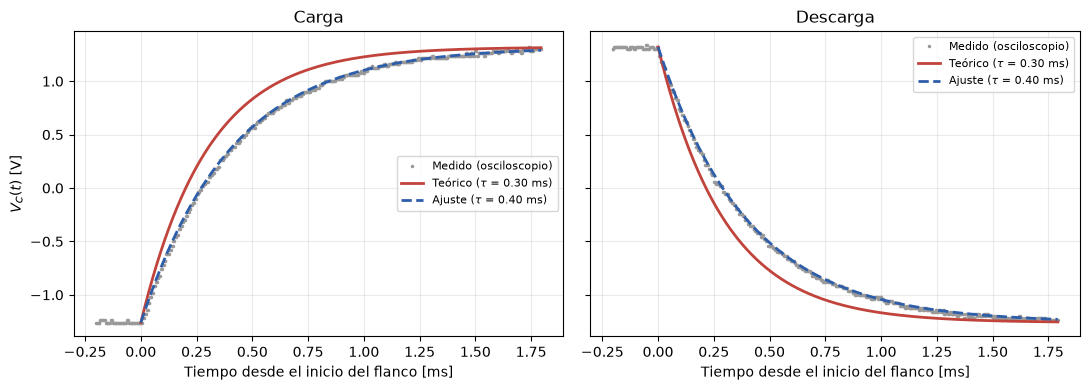

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, (i, es_carga), titulo in zip(axs, [[f for f in flancos if f[1]][1], [f for f in flancos if not f[1]][0]], ["Carga", "Descarga"]):
    _, t0 = ajustar_tau(i, es_carga)
    a = int((t0 - 0.2e-3) / dt)
    b = int((t0 + 1.8e-3) / dt)
    tt = t_med[a:b] - t0
    tp = np.linspace(0, tt[-1], 400)
    if es_carga:
        f = lambda x, tau: v_bajo + (v_alto - v_bajo) * (1 - np.exp(-x / tau))
    else:
        f = lambda x, tau: v_bajo + (v_alto - v_bajo) * np.exp(-x / tau)

    ax.plot(tt * 1e3, v_med[a:b], ".", color="0.6", markersize=3, label="Medido (osciloscopio)")
    ax.plot(tp * 1e3, f(tp, tau_teo), color="#C1443C", linewidth=2, label=fr"Teórico ($\tau$ = {tau_teo*1e3:.2f} ms)")
    ax.plot(tp * 1e3, f(tp, tau_med), "--", color="#2E5EAA", linewidth=2, label=fr"Ajuste ($\tau$ = {tau_med*1e3:.2f} ms)")
    ax.set_title(titulo)
    ax.set_xlabel("Tiempo desde el inicio del flanco [ms]")
    ax.grid(alpha=0.25)
    ax.legend(loc="center right" if es_carga else "upper right", fontsize=8)

axs[0].set_ylabel(r"$V_C(t)$ [V]")
fig.tight_layout()
plt.show()

### 7.3. Señal completa: medición vs. muestra teórica a 200 Hz

Se simula la respuesta del circuito RC a una onda cuadrada de $200\,Hz$ (la del generador), con el flanco de carga alineado al primer flanco medido y con los mismos niveles alto y bajo que la señal real. Así la única diferencia entre las curvas es el valor de $\tau$: el teórico ($RC$) y el medido.

Residuo RMS con tau teórico (0.30 ms) = 159 mV
Residuo RMS con tau medido  (0.40 ms) = 25 mV


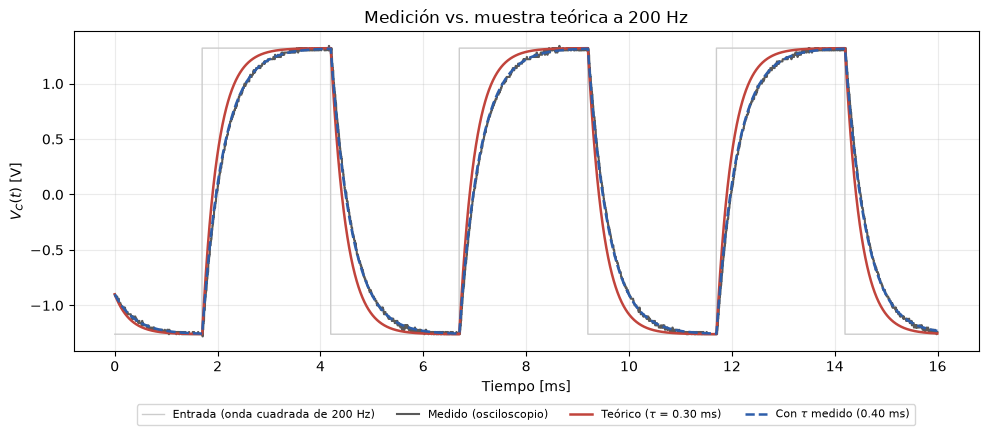

In [13]:
f_generador = 200                                  # frecuencia configurada en el generador [Hz]
T_gen = 1 / f_generador
t_inicio = ajustar_tau(*[f for f in flancos if f[1]][0])[1]   # instante del primer flanco de carga

def respuesta_rc(tau_rc):
    # Entrada: onda cuadrada entre v_bajo y v_alto. La salida se avanza muestra a muestra
    # con la solución exacta del RC para una entrada constante entre muestras.
    en_alto = (t_med >= t_inicio) & (((t_med - t_inicio) % T_gen) < T_gen / 2)
    v_in = np.where(en_alto, v_alto, v_bajo)
    a = 1 - np.exp(-dt / tau_rc)
    v = np.empty_like(v_in)
    v[0] = v_med[0]
    for n in range(len(v) - 1):
        v[n + 1] = v[n] + (v_in[n] - v[n]) * a
    return v_in, v

v_in, v_teo = respuesta_rc(tau_teo)
_, v_aj = respuesta_rc(tau_med)

mascara = t_med > t_inicio - 0.5e-3               # se evita el arranque, que depende del estado previo
rms_teo = np.sqrt(np.mean((v_med[mascara] - v_teo[mascara]) ** 2))
rms_aj = np.sqrt(np.mean((v_med[mascara] - v_aj[mascara]) ** 2))
print(f"Residuo RMS con tau teórico ({tau_teo*1e3:.2f} ms) = {rms_teo*1e3:.0f} mV")
print(f"Residuo RMS con tau medido  ({tau_med*1e3:.2f} ms) = {rms_aj*1e3:.0f} mV")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t_med * 1e3, v_in, color="0.8", linewidth=1, label="Entrada (onda cuadrada de 200 Hz)")
ax.plot(t_med * 1e3, v_med, color="0.35", linewidth=1.5, label="Medido (osciloscopio)")
ax.plot(t_med * 1e3, v_teo, color="#C1443C", linewidth=1.8, label=fr"Teórico ($\tau$ = {tau_teo*1e3:.2f} ms)")
ax.plot(t_med * 1e3, v_aj, "--", color="#2E5EAA", linewidth=1.8, label=fr"Con $\tau$ medido ({tau_med*1e3:.2f} ms)")
ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel(r"$V_C(t)$ [V]")
ax.set_title("Medición vs. muestra teórica a 200 Hz")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4)
fig.tight_layout()
plt.show()

### 7.4. Frecuencia del generador: criterio de diseño vs. usada

Una primera estimación de la frecuencia daba $\approx 333,3\,Hz$. Esa frecuencia **no es una condición del circuito**, sino un criterio de diseño: es la que hace que cada fase dure exactamente $5\tau$ con el $\tau = RC$ teórico. Cualquier frecuencia sirve mientras cada fase dure varios $\tau$ (al menos unos $5\tau$), de modo que el capacitor llegue a cargarse y descargarse casi por completo.

En la práctica el generador de funciones se configuró en **200 Hz**, y la muestra teórica de este notebook se calculó con esa misma frecuencia para poder compararla con la medición en igualdad de condiciones. Se puede verificar en la captura con el tiempo entre flancos de carga consecutivos, y calcular qué fracción del valor final alcanza el capacitor en cada fase con el $\tau$ medido:

In [14]:
T_usado = np.mean(np.diff([i for i, es_carga in flancos if es_carga])) * dt
f_usada = 1 / T_usado
f_generador = 200                   # frecuencia configurada en el generador [Hz]
f_sug = 1 / (10 * tau_teo)          # frecuencia sugerida en la muestra teórica
f_10tau = 1 / (10 * tau_med)        # la que daría exactamente 5*tau con el tau medido

print(f"Frecuencia del generador         = {f_generador} Hz")
print(f"Frecuencia medida en la captura  = {f_usada:.0f} Hz  (T = {T_usado*1e3:.2f} ms)")
print(f"Frecuencia sugerida (teórica)    = {f_sug:.1f} Hz")
print(f"Frecuencia para 5*tau_medido     = {f_10tau:.0f} Hz\n")

for nombre, f in [("usada", f_usada), ("sugerida", f_sug)]:
    fase = 1 / (2 * f)
    print(f"f {nombre:9s}: cada fase dura {fase*1e3:.2f} ms = {fase/tau_med:.1f} tau medidos "
          f"-> el capacitor alcanza el {(1 - np.exp(-fase/tau_med))*100:.1f} % del valor final")

Frecuencia del generador         = 200 Hz
Frecuencia medida en la captura  = 200 Hz  (T = 5.01 ms)
Frecuencia sugerida (teórica)    = 333.3 Hz
Frecuencia para 5*tau_medido     = 248 Hz

f usada    : cada fase dura 2.50 ms = 6.2 tau medidos -> el capacitor alcanza el 99.8 % del valor final
f sugerida : cada fase dura 1.50 ms = 3.7 tau medidos -> el capacitor alcanza el 97.6 % del valor final


Como el $\tau$ real ($\approx 0,40\,ms$) es mayor que el teórico, con los $333\,Hz$ sugeridos cada fase duraría solo $\approx 3,7\tau$ reales y el capacitor no llegaría a estabilizarse del todo. Con la frecuencia usada ($200\,Hz$, que coincide con la medida en la captura) cada fase dura $\approx 6\tau$ reales: el capacitor llega a su valor final y se ve un tramo plano antes de cada flanco, lo que además mejora el ajuste de $\tau$. Por eso la frecuencia usada resulta una mejor elección que la del criterio de $5\tau$ teórico; lo que hay que cuidar es que la fase sea suficientemente larga respecto del $\tau$ real del circuito.

### 7.5. Análisis de las mediciones

* La forma de la señal medida es la esperada: exponenciales de carga y descarga, y la señal se estabiliza en cada nivel antes de que llegue el siguiente flanco.
* El $\tau$ medido es $\tau = (0,404 \pm 0,008)\,ms$ (promedio de los 6 flancos, con la desviación estándar como error). La dispersión entre flancos es de apenas un $2\%$, mientras que la diferencia con el teórico ($0,30\,ms$) es de un $35\%$: **no es una dispersión de la medición, la diferencia es sistemática**.
* La causa es la **resistencia de salida del generador de funciones**: según las especificaciones del fabricante, el GW Instek AFG-2005 tiene una impedancia de salida de $50\,\Omega$, que queda en serie con $R$. Con $R_{tot} = 150 + 50 = 200\,\Omega$ resulta $\tau = 200 \cdot 2\times10^{-6} = 0,40\,ms$, que coincide con lo medido. La pequeña diferencia restante puede atribuirse a las tolerancias de $R$ y $C$ (un capacitor puede tener $\pm 10\text{-}20\%$).
* Si se separan los flancos, los de carga dan un $\tau$ levemente mayor ($\approx 0,410\,ms$) que los de descarga ($\approx 0,397\,ms$). La diferencia es chica (un $3\%$) pero se repite en todos los ciclos, así que tampoco parece ruido; podría deberse a que la salida del generador no se comporta exactamente igual en el nivel alto que en el bajo (los niveles medidos tampoco son simétricos: $+1,32\,V$ y $-1,26\,V$). No cambia las conclusiones sobre $\tau$.
* Como el semiperíodo de la señal es de unos $2,5\,ms$ ($\approx 6\tau$ medido), el capacitor llega a cargarse y descargarse casi por completo en cada flanco, igual que en la muestra teórica de $200\,Hz$.
* En la comparación con la muestra teórica en las mismas condiciones ($200\,Hz$, mismos niveles de tensión) se ve que la curva con el $\tau$ teórico se "adelanta": carga y descarga más rápido que lo medido, mientras que la de $\tau$ medido acompaña los datos. Los residuos lo confirman (ver arriba).
* La excursión medida es de unos $2,6\,V$ pico a pico, la mitad de los $5\,V$ que entregaba el generador ($V_0 = 5V$). Esto se debe a la configuración del osciloscopio: como figura en el encabezado del archivo, la sonda estaba configurada en `Probe = 0.5X`, por lo que las tensiones mostradas quedan multiplicadas por $0,5$. Corrigiendo ese factor, la excursión real es de $2,58 \times 2 \approx 5,2\,V$, que coincide con $V_0$. Además la señal es simétrica respecto de $0\,V$: el generador entrega una onda cuadrada de $\pm 2,5\,V$, así que el capacitor va de $-V_0/2$ a $+V_0/2$ (una excursión total de $V_0$) en lugar de ir de $0$ a $V_0$ como en la muestra teórica. Ninguna de las dos cosas **afecta el valor de $\tau$**, que depende solo de la forma temporal de la señal.

## 8. Conclusiones

El modelo teórico de carga y descarga ($\tau=RC$, con las exponenciales $V_C(t)$ e $I(t)$) sirvió para elegir cómo configurar la medición: con $\tau_{teórico}=0,30\,ms$, una onda cuadrada de $200\,Hz$ deja cada fase de $2,5\,ms$ ($\approx 8\tau$), tiempo de sobra para que el capacitor se cargue y descargue casi por completo antes de cada flanco.

La medición con el osciloscopio confirmó la forma exponencial esperada de la señal, con una constante de tiempo $\tau_{medido} = (0,404 \pm 0,008)\,ms$. Este valor es un $35\%$ mayor que el teórico ($0,30\,ms$), una diferencia mucho más grande que la dispersión entre los 6 flancos capturados ($2\%$): no es dispersión de la medición, es una diferencia sistemática. Hay dos explicaciones posibles, y ambas son consistentes con lo medido:

1. **La resistencia de salida del generador de funciones** (GW Instek AFG-2005, $50\,\Omega$ según el fabricante) queda en serie con $R$: sumándola ($R_{tot}=200\,\Omega$) el $\tau$ teórico pasa a ser $0,40\,ms$ y coincide con el medido. El modelo $\tau = RC$ es correcto siempre que $R$ incluya **todas** las resistencias del circuito, también la interna de la fuente.
2. **El capacitor no es exactamente de $2\,\mu F$.** Como $R$ es un valor bastante confiable (resistencia de película) y $C$ tiene tolerancias de fabricación típicas de $\pm 10$-$20\%$, se puede despejar $C = \tau/R$ a partir de lo medido (sección 7.1.1): da $C_{medido} = (2,69\pm0,05)\,\mu F$, también un $35\%$ por encima del nominal, y consistente entre los 6 flancos.

Con los datos de este trabajo no se puede distinguir cuál de las dos es la causa real (o si son ambas en menor medida cada una) — para eso haría falta medir $C$ por separado con un capacímetro, o repetir la captura con una $R$ mucho más grande (para que los $50\,\Omega$ del generador dejen de ser relevantes) y ver si $\tau_{medido}$ se corrige.

La amplitud medida ($\approx 2,6\,V$ pico a pico) resultó la mitad de los $5\,V$ que entregaba el generador porque la sonda estaba configurada en `0.5X` en el osciloscopio: corrigiendo ese factor se obtienen $\approx 5,2\,V$, en acuerdo con $V_0 = 5V$. Esto no afecta a $\tau$.

Un punto importante del trabajo fue elegir bien la frecuencia de la señal para que la comparación teoría-medición tuviera sentido: el criterio de $5\tau$ con el $\tau$ teórico sugeriría $\approx 333\,Hz$, pero se usó $200\,Hz$ (la configurada en el generador) tanto en la muestra teórica como en la medición. En los hechos, $200\,Hz$ resultó una elección igual de buena o mejor: como el $\tau$ real es mayor al teórico, a $200\,Hz$ cada fase dura $\approx 6\tau$ reales (el capacitor llega a estabilizarse), mientras que a $333\,Hz$ solo llegaría a $\approx 3,7\tau$ reales.

Para futuras mediciones conviene incluir la resistencia de salida del generador desde el diseño ($\tau = (R + R_{gen}).C$), medir $R$ y $C$ con instrumentos para acotar sus tolerancias, y verificar que el factor de sonda configurado en el osciloscopio coincida con la sonda usada.